In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/sample_2.csv')
print(df.shape)
df.head()

(34719, 15)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2013,Hyundai,Elantra,Limited,Sedan,automatic,5npdh4ae1dh194798,fl,25.0,32997.0,black,gray,hyundai motor finance,13200.0,Tue Jan 06 2015 01:30:00 GMT-0800 (PST)
1,2008,NaN,NaN,NaN,NaN,automatic,1fdns24l58da70495,ga,33.0,85037.0,black,black,akins ford dodge jeep chrysler,17800.0,Thu Jan 15 2015 02:00:00 GMT-0800 (PST)
2,2011,Nissan,Maxima,3.5 SV,Sedan,automatic,1n4aa5ap0bc867447,mo,42.0,65192.0,white,beige,nissan-infiniti lt,15700.0,Wed Feb 18 2015 02:30:00 GMT-0800 (PST)
3,2014,Chevrolet,Impala,LT,Sedan,NaN,2g1125s35e9281298,co,3.0,27296.0,white,gray,gm remarketing,23100.0,Tue Jun 16 2015 04:30:00 GMT-0700 (PDT)
4,2013,Chevrolet,Silverado 1500,LT,Extended Cab,automatic,1gcrcse04dz214378,ga,45.0,20770.0,silver,black,young motors llc,23300.0,Tue Jan 06 2015 01:30:00 GMT-0800 (PST)


In [18]:
# veiw missing values
df.isnull().sum()

year               0
make             647
model            651
trim             678
body             820
transmission    4038
vin                1
state              0
condition        717
odometer           5
color             48
interior          48
seller             0
sellingprice       4
saledate           5
dtype: int64

In [19]:
df['make'].fillna(df['make'].mode()[0], inplace=True)
df['model'].fillna(df['model'].mode()[0], inplace=True)
df['trim'].fillna(df['trim'].mode()[0], inplace=True)
df['body'].fillna(df['body'].mode()[0], inplace=True)
df['transmission'].fillna(df['transmission'].mode()[0], inplace=True)
df['color'].fillna(df['color'].mode()[0], inplace=True)
df['interior'].fillna(df['interior'].mode()[0], inplace=True)
df['condition'].fillna(df['condition'].median(), inplace=True)
df['odometer'].fillna(df['odometer'].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_187/614416313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['make'].fillna(df['make'].mode()[0], inplace=True)
/tmp/ipykernel_187/614416313.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             1
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
sellingprice    4
saledate        5
dtype: int64

In [20]:
df.dropna(inplace=True)
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
sellingprice    0
saledate        0
dtype: int64

In [21]:
df.describe()

,year,condition,odometer,sellingprice
count,34713.000000,34713.000000,34713.000000,34713.000000
mean,2010.028980,30.734221,68325.177398,13639.261343
std,4.003473,13.286471,53335.791751,9795.670007
min,1986.000000,1.000000,1.000000,100.000000
25%,2007.000000,24.000000,28372.000000,7000.000000
50%,2012.000000,35.000000,52342.000000,12200.000000
75%,2013.000000,41.000000,99270.000000,18200.000000
max,2015.000000,49.000000,999999.000000,163000.000000


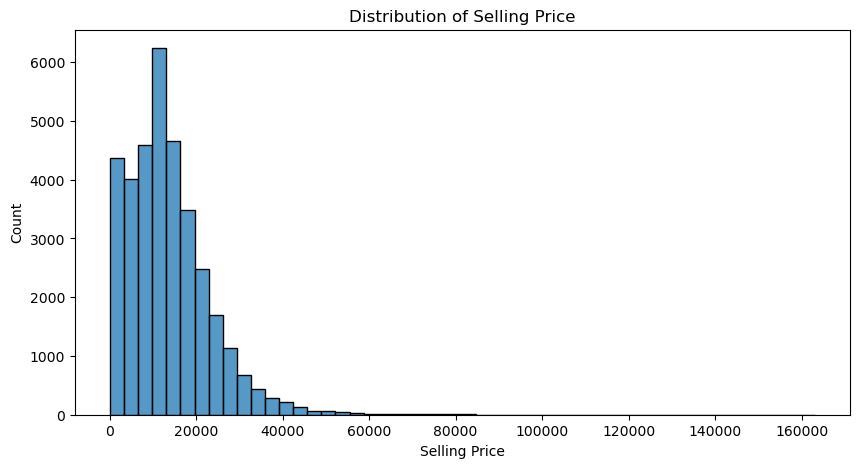

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sellingprice'], bins=50)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()

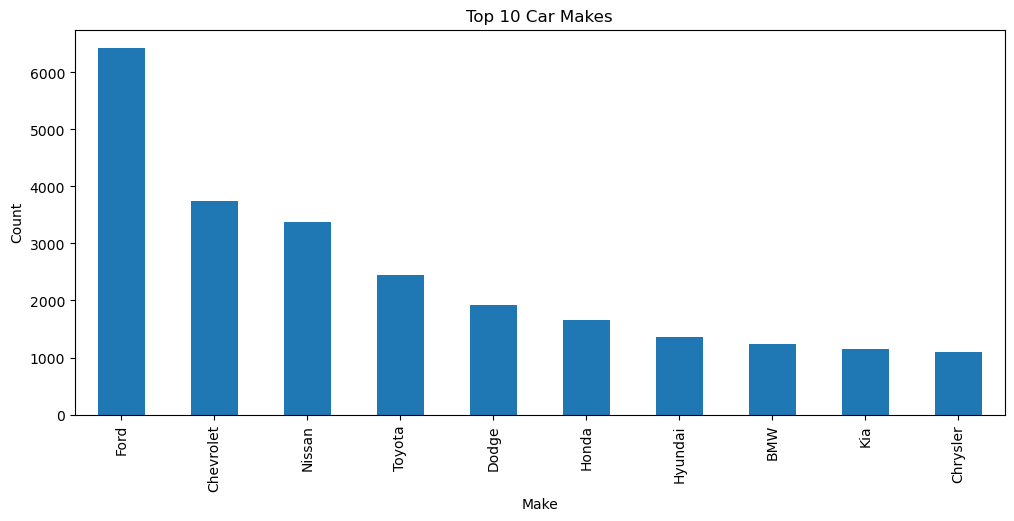

In [23]:
plt.figure(figsize=(12, 5))
df['make'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Car Makes')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

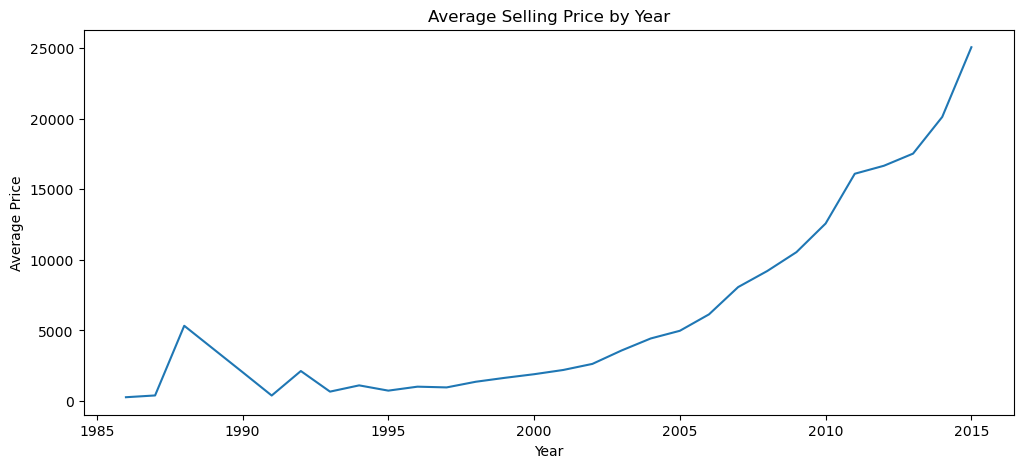

In [24]:
plt.figure(figsize=(12, 5))
df.groupby('year')['sellingprice'].mean().plot(kind='line')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.show()

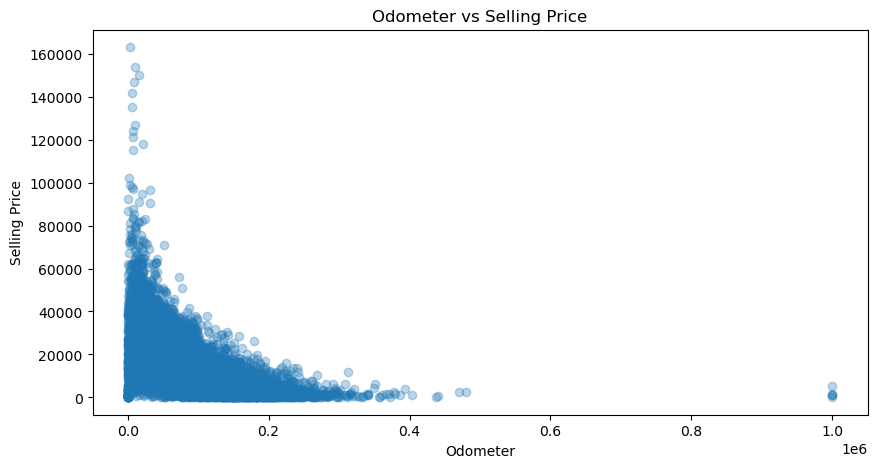

In [25]:
plt.figure(figsize=(10, 5))
plt.scatter(df['odometer'], df['sellingprice'], alpha=0.3)
plt.title('Odometer vs Selling Price')
plt.xlabel('Odometer')
plt.ylabel('Selling Price')
plt.show()

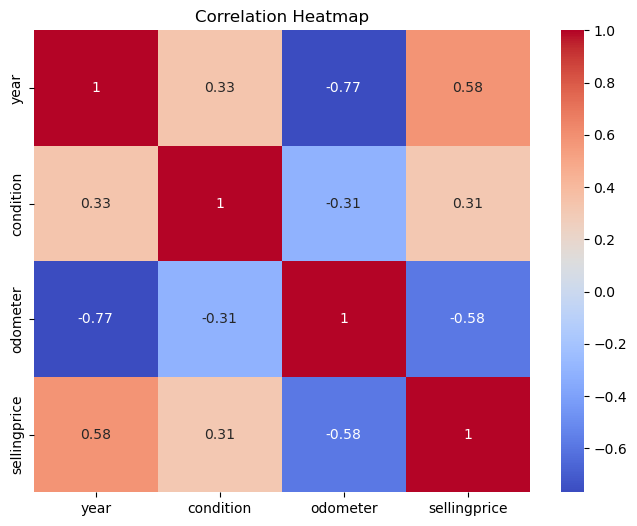

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['year', 'condition', 'odometer', 'sellingprice']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Conclusions: Feature Importance for Selling Price Prediction

**Most important features:**
- `year` — correlation 0.58 with price. Newer cars are more expensive.
- `odometer` — correlation -0.58 with price. More mileage = lower price.
- `condition` — correlation 0.31. Better condition = higher price.

**Features that are hard to process:**
- `vin` — unique identifier for each car, not useful for prediction.
- `saledate` — date in text format, needs parsing to extract useful info.
- `seller` — too many unique values, hard to encode effectively.
- `make`, `model`, `trim` — categorical with hundreds of unique values, need careful encoding.